In [1]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from transformers import pipeline
from dotenv import load_dotenv
import os
import sys
sys.path.append('../Src')
from Src.config import CLEANED_DATA, ANALYZED_DATA
load_dotenv()
df = pd.read_csv(CLEANED_DATA)

In [2]:
df['created_at_dt']      = pd.to_datetime(df['created_at'], format='%a %b %d %H:%M:%S %z %Y', errors='coerce')
df['user_created_at_dt'] = pd.to_datetime(df['user_created_at'], format='%a %b %d %H:%M:%S %z %Y', errors='coerce')
df['view_count']         = pd.to_numeric(df['view_count'], errors='coerce').fillna(0)
df['user_followers_count'] = pd.to_numeric(df['user_followers_count'], errors='coerce').fillna(0)
df['user_statuses_count']  = pd.to_numeric(df['user_statuses_count'], errors='coerce').fillna(0)
df['retweet_count']      = pd.to_numeric(df['retweet_count'], errors='coerce').fillna(0)
df['favorite_count']     = pd.to_numeric(df['favorite_count'], errors='coerce').fillna(0)

# Parse mentions dari string list JSON
df['mentions_parsed'] = df['mentions'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else []
)
df['mention_count'] = df['mentions_parsed'].apply(len)

print(f"Shape: {df.shape}")
print(f"Kolom tersedia: {df.columns.tolist()}")

Shape: (15000, 37)
Kolom tersedia: ['date', 'lang', 'source', 'user_id', 'hashtags', 'is_quote', 'mentions', 'tweet_id', 'username', 'verified', 'full_text', 'created_at', 'quoted_url', 'view_count', 'quote_count', 'quoted_text', 'reply_count', 'display_name', 'retweet_count', 'user_location', 'favorite_count', 'in_reply_to_url', 'quoted_tweet_id', 'quoted_username', 'user_created_at', 'user_description', 'in_reply_to_user_id', 'user_statuses_count', 'user_followers_count', 'user_following_count', 'in_reply_to_status_id', 'in_reply_to_screen_name', 'clean_text', 'created_at_dt', 'user_created_at_dt', 'mentions_parsed', 'mention_count']


In [3]:
vader = SentimentIntensityAnalyzer()

indo_lexicon = {
    # Positif
    'bagus': 2.0, 'baik': 1.5, 'hebat': 2.5, 'mantap': 2.0, 'keren': 2.0,
    'setuju': 1.5, 'dukung': 1.5, 'sukses': 2.0, 'berhasil': 2.0, 'manfaat': 1.5,
    'bermanfaat': 2.0, 'sejahtera': 2.0, 'meningkat': 1.0, 'berkembang': 1.0,
    'inovatif': 1.5, 'kreatif': 1.5, 'optimal': 1.5, 'efektif': 1.5,
    'transparan': 1.5, 'merata': 1.5, 'tepat': 1.0, 'lancar': 1.0,
    'senang': 2.0, 'bangga': 2.0, 'harap': 1.0, 'semangat': 1.5,

    # Negatif
    'buruk': -2.0, 'jelek': -2.0, 'gagal': -2.5, 'kacau': -2.5, 'bohong': -2.5,
    'korupsi': -3.0, 'manipulasi': -2.5, 'pencitraan': -2.0, 'sia': -1.5,
    'mubazir': -2.0, 'buang': -1.5, 'curang': -2.5, 'nepotisme': -2.5,
    'lambat': -1.5, 'terlambat': -1.5, 'tidak': -1.0, 'belum': -0.5,
    'mahal': -1.5, 'boros': -2.0, 'sia-sia': -2.0, 'percuma': -2.0,
    'kritik': -1.0, 'tolak': -2.0, 'protes': -1.5, 'kecewa': -2.5,
    'khawatir': -1.5, 'takut': -1.5, 'rugi': -2.0, 'susah': -1.5,

    # Netral/konteks
    'propaganda': -2.0, 'politis': -1.0,
}

mbg_specific = {
    # Dari temuan frame keamanan_pangan
    'keracunan': -3.0, 'basi': -2.5, 'busuk': -2.5, 'mati': -2.5,
    'racun': -3.0, 'beracun': -3.0,
    # Dari frame anggaran
    'korupsi': -3.0, 'mark up': -2.5, 'fiktif': -2.5,
    # Dari frame dukungan
    'bergizi': 1.5, 'gratis': 1.0, 'lanjutkan': 1.5,
    # Dari buzzer_hype
    'buzzer': -1.5, 'bot': -1.5, 'astroturfing': -2.0,
}

# 3. GABUNGKAN KAMUS TERLEBIH DAHULU (PENTING!)
indo_lexicon.update(mbg_specific)
vader.lexicon.update(indo_lexicon)

# 4. Fungsi Sentimen
def get_sentiment_vader(text):
    if pd.isna(text) or str(text).strip() == '':
        return 'netral', 0.0

    scores = vader.polarity_scores(str(text))
    compound = scores['compound']

    if compound >= 0.02:
        return 'positif', compound
    elif compound <= -0.02:
        return 'negatif', compound
    else:
        return 'netral', compound

# 5. Apply ke DataFrame dengan cara yang jauh lebih cepat
# tolist() mengubah tuple menjadi list of tuples, yang bisa langsung diassign ke 2 kolom
df[['sentiment_vader', 'sentiment_score']] = df['clean_text'].apply(get_sentiment_vader).tolist()

# 6. Print Hasil
print("Distribusi Sentiment (VADER):")
print(df['sentiment_vader'].value_counts())
print("\nPersentase:")
print(df['sentiment_vader'].value_counts(normalize=True).mul(100).round(1))

Distribusi Sentiment (VADER):
sentiment_vader
netral     8693
positif    3378
negatif    2929
Name: count, dtype: int64

Persentase:
sentiment_vader
netral     58.0
positif    22.5
negatif    19.5
Name: proportion, dtype: float64


In [4]:
frame_keywords = {
    'ekonomi': [
        'umkm', 'katering', 'usaha', 'bisnis', 'ekonomi', 'pendapatan',
        'lapangan', 'kerja', 'supplier', 'bahan', 'pangan', 'harga',
        'pasar', 'petani', 'nelayan', 'subsidi', 'biaya', 'untung',
        'modal', 'omzet', 'produksi', 'komoditas', 'penjual', 'warung'
    ],
    'anggaran_fiskal': [
        'anggaran', 'dana', 'apbn', 'uang', 'trilun', 'miliar', 'rupiah',
        'fiskal', 'keuangan', 'sri mulyani', 'pajak', 'defisit', 'utang',
        'hutang', 'alokasi', 'pemotongan', 'efisiensi', 'potong', 'gaji',
        'korupsi', 'kkn', 'kroni', 'nepotisme', 'proyek'
    ],
    'gizi_kesehatan': [
        'gizi', 'sehat', 'nutrisi', 'vitamin', 'protein', 'stunting',
        'tumbuh', 'kembang', 'anak', 'siswa', 'pelajar', 'belajar',
        'konsentrasi', 'imun', 'kalori', 'menu', 'sayur', 'buah',
        'sakit', 'keracunan', 'mual', 'diare', 'basi', 'higienis'
    ],
    'keamanan_pangan': [
        'racun', 'beracun', 'keracunan', 'basi', 'busuk', 'kotor',
        'higienis', 'sanitasi', 'berbahaya', 'mati', 'sakit', 'rumah sakit',
        'oplos', 'oplosan', 'kimia', 'bahaya', 'percobaan', 'bunuh',
        'korban', 'tewas', 'meninggal'
    ],
    'kebijakan_implementasi': [
        'distribusi', 'implementasi', 'pelaksanaan', 'penyaluran',
        'target', 'sasaran', 'infrastruktur', 'koordinasi', 'dinas',
        'kemenag', 'kemendikbud', 'sekolah', 'pesantren', 'regulasi',
        'aturan', 'prosedur', 'mekanisme', 'pengadaan', 'tender',
        'merata', 'belum', 'dapur', 'unit', 'jadwal', 'terlambat',
        'evaluasi', 'monitoring', 'pengawasan'
    ],
    'political_skeptis': [
        'pencitraan', 'politik', 'politis', 'pilkada', 'pemilu', 'partai',
        'kampanye', 'janji', 'manipulasi', 'bohong', 'rezim', 'jokowi',
        'prabowo', 'presiden', 'perintah', 'gerombolan', 'antek',
        'elite', 'oligarki', 'kepentingan', 'populis', 'gemoy',
        'keluarga', 'kroni', 'kekuasaan', 'bencana'
    ],
    'dukungan_umum': [
        'dukung', 'dukungan', 'lanjutkan', 'terus', 'semangat', 'bagus',
        'keren', 'mantap', 'hebat', 'berhasil', 'sukses', 'bangga',
        'terima kasih', 'apresiasi', 'salut', 'Indonesia maju',
        'emas', 'masa depan', 'generasi', 'bangsa', 'cinta'
    ],
    'buzzer_hype': [
        'buzzer', 'bot', 'massal', 'serentak', 'tagar', 'trending',
        'viral', 'endorse', 'berbayar', 'bayaran', 'koordinasi'
    ],
    'agama_budaya': [
        'halal', 'haram', 'pesantren', 'santri', 'ulama', 'kyai',
        'agama', 'islam', 'kristen', 'hindu', 'budaya', 'adat',
        'lokal', 'tradisional', 'kearifan', 'masjid', 'gereja'
    ],
    'sosial_pemerataan': [
        'miskin', 'dhuafa', 'pelosok', 'desa', 'terpencil', 'merata',
        'adil', 'keadilan', 'kesenjangan', 'marginal', 'disabilitas',
        'yatim', 'panti', 'sulawesi', 'papua', 'daerah', 'wilayah'
    ]
}

frame_keywords['resistensi_regional'] = [
    'papua', 'mbgpapua', 'anak papua', 'tokoh adat', 'tolak', 'papua tolak',
    'aceh', 'sulawesi', 'kalimantan', 'lokal', 'daerah terpencil', 'pelosok'
]

frame_keywords['gizi_kesehatan'] = [
    kw for kw in frame_keywords['gizi_kesehatan']
    if kw not in frame_keywords['keamanan_pangan']
]


keamanan_kualitas_kw = ['menu', 'basi', 'busuk', 'kotor', 'tidak higienis', 'serangga', 'nasi']
keamanan_insiden_kw  = ['keracunan', 'racun', 'korban', 'siswa sakit', 'kasus racun', 'rumah sakit', 'tewas']

kata_fatal = [
    'keracunan', 'racun', 'beracun', 'basi', 'busuk', 'mati', 'tewas',
    'korupsi', 'mark up', 'fiktif', 'kotor', 'belatung', 'oplosan'
]

def detect_keamanan_subframe(text):
    if pd.isna(text) or str(text).strip() == '':
        return None
    t = str(text).lower()
    is_insiden  = any(kw in t for kw in keamanan_insiden_kw)
    is_kualitas = any(kw in t for kw in keamanan_kualitas_kw)

    if is_insiden:
        return 'insiden_keracunan'
    if is_kualitas:
        return 'kualitas_menu'
    return None

def detect_frame(text):
    if pd.isna(text) or str(text).strip() == '':
        return 'tidak_terklasifikasi'

    text_lower = str(text).lower()
    frame_scores = {}

    for frame, keywords in frame_keywords.items():
        score = sum(1 for kw in keywords if kw in text_lower)
        if score > 0:
            frame_scores[frame] = score

    if not frame_scores:
        return 'tidak_terklasifikasi'

    return max(frame_scores, key=frame_scores.get)

def detect_all_frames(text):
    if pd.isna(text) or str(text).strip() == '':
        return []
    text_lower = str(text).lower()
    return [
        frame for frame, keywords in frame_keywords.items()
        if any(kw in text_lower for kw in keywords)
    ]

df['keamanan_subframe'] = df['clean_text'].apply(detect_keamanan_subframe)
df['frame_utama']       = df['clean_text'].apply(detect_frame)
df['all_frames']        = df['clean_text'].apply(detect_all_frames)

print("Distribusi Frame Utama:")
print(df['frame_utama'].value_counts())

print("\nDistribusi Sub-Frame Keamanan:")
print(df['keamanan_subframe'].value_counts())

Distribusi Frame Utama:
frame_utama
tidak_terklasifikasi      4267
gizi_kesehatan            3194
ekonomi                   1629
anggaran_fiskal           1629
dukungan_umum             1115
keamanan_pangan            945
political_skeptis          921
kebijakan_implementasi     909
sosial_pemerataan          158
buzzer_hype                100
resistensi_regional         97
agama_budaya                36
Name: count, dtype: int64

Distribusi Sub-Frame Keamanan:
keamanan_subframe
insiden_keracunan    1408
kualitas_menu        1015
Name: count, dtype: int64


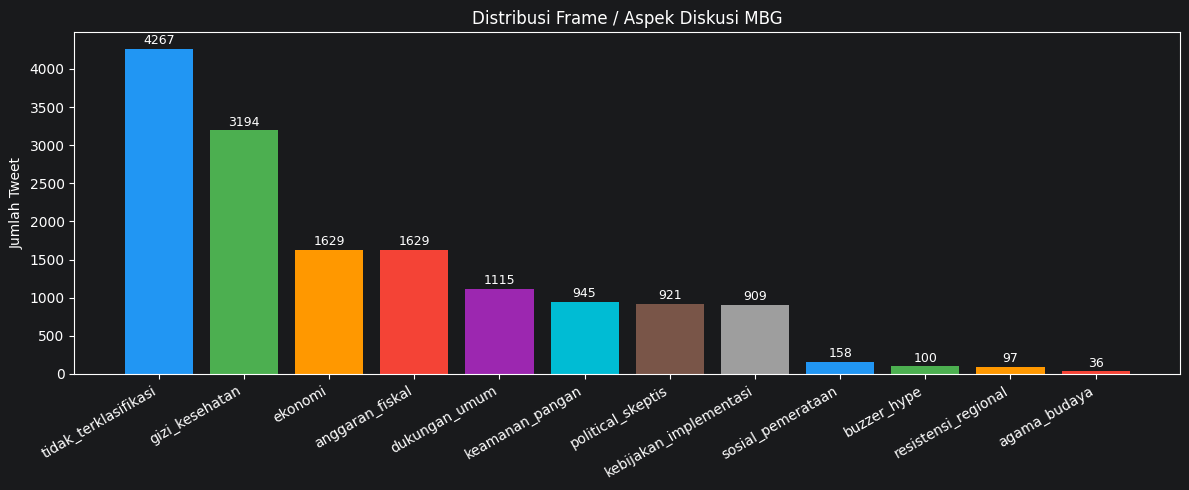

In [5]:
plt.figure(figsize=(12, 5))
frame_counts = df['frame_utama'].value_counts()
colors = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0','#00BCD4','#795548','#9E9E9E']
bars = plt.bar(frame_counts.index, frame_counts.values, color=colors[:len(frame_counts)])
plt.xticks(rotation=30, ha='right')
plt.title('Distribusi Frame / Aspek Diskusi MBG')
plt.ylabel('Jumlah Tweet')
for bar, val in zip(bars, frame_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

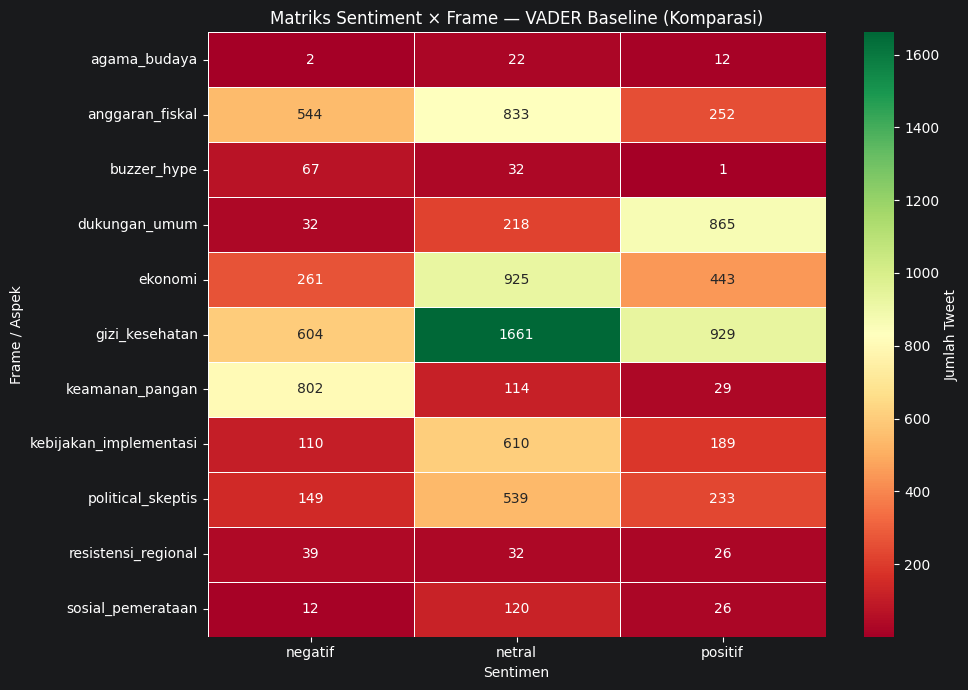

In [6]:
pivot_sf = pd.crosstab(df['frame_utama'], df['sentiment_vader'])

# Buang baris tidak_terklasifikasi biar bersih
pivot_sf = pivot_sf.drop('tidak_terklasifikasi', errors='ignore')

plt.figure(figsize=(10, 7))
sns.heatmap(
    pivot_sf,
    annot=True, fmt='d',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Jumlah Tweet'}
)
# --- TAMBAHAN DARI AI: Ubah judul heatmap ---
plt.title('Matriks Sentiment × Frame — VADER Baseline (Komparasi)')
plt.xlabel('Sentimen')
plt.ylabel('Frame / Aspek')
plt.tight_layout()
plt.show()

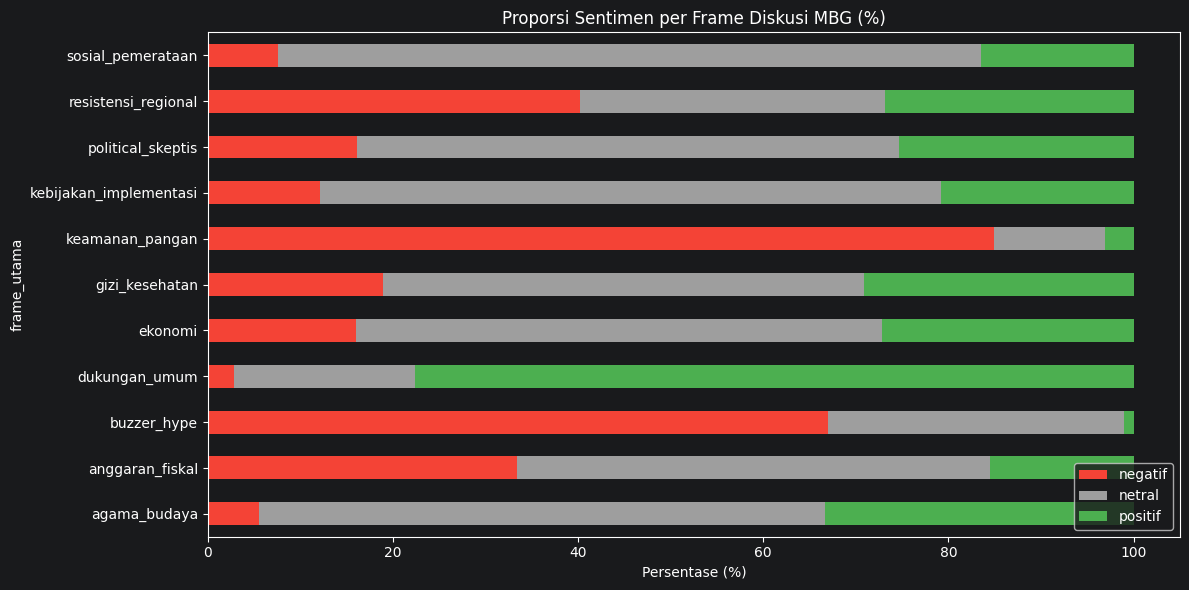

In [7]:
pivot_pct = pivot_sf.div(pivot_sf.sum(axis=1), axis=0) * 100

pivot_pct.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 6),
    color={'positif': '#4CAF50', 'negatif': '#F44336', 'netral': '#9E9E9E'}
)
plt.title('Proporsi Sentimen per Frame Diskusi MBG (%)')
plt.xlabel('Persentase (%)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [8]:
for frame in df['frame_utama'].unique():
    if frame == 'tidak_terklasifikasi':
        continue
    for sent in ['positif', 'negatif']:
        subset = df[(df['frame_utama'] == frame) & (df['sentiment_vader'] == sent)]
        if len(subset) > 0:
            sample = subset['full_text'].sample(1, random_state=42).values[0]
            print(f"\n[{frame.upper()} | {sent.upper()}]")
            print(f"  {sample[:150]}...")


[KEBIJAKAN_IMPLEMENTASI | POSITIF]
  gak cape apa nyapuin pemerintah terus wkwkwk
lagian apa salah nya dah komplen?itu kan hak mereka justru bisa jadi koreksi kedepan untuk regulasi MBG n...

[KEBIJAKAN_IMPLEMENTASI | NEGATIF]
  Sedih :(
Ingin rasanya kirim video ini ke orang² yg kemaren pilih ni rezim dgn alasan biar papua dapet mbg.
Bodoh, padahal sekolah tinggi....

[GIZI_KESEHATAN | POSITIF]
  Gizi cukup, prestasi meningkat!
Dukung terus Program MBG demi generasi sehat dan cerdas.
#LanjutkanMBG

#GMMTVFANIVALxPondPhuwin #PPPFAMILYATFANIVAL #...

[GIZI_KESEHATAN | NEGATIF]
  @somexthread MBG sumber malapetaka keracunan Anak Bangsa...

[EKONOMI | POSITIF]
  @Hasbil_Lbs Satu dua kasus sengaja di blow up seolah2 semua bermasalah. Padahal keberhasilan program ini juga dirasakan manfaatnya oleh banyak masyara...

[EKONOMI | NEGATIF]
  @PNS_Ababil Efisiensi kalau tujuannya jelas gpp. Tapi kalau demi mbg. Kok ga rela. Soalnya yang dikasi ga semuanya anak susah. Seharusnya yg diperbaik...


In [9]:
tidak_ter = df[df['frame_utama'] == 'tidak_terklasifikasi']['clean_text'].dropna()

words_tidak = " ".join(tidak_ter).split()
top_words = Counter(words_tidak).most_common(40)

print("\nTOP 40 KATA di tweet TIDAK TERKLASIFIKASI")
for word, count in top_words:
    print(f"  {word}: {count}")

print("\n20 SAMPLE TWEET TIDAK TERKLASIFIKASI")
for t in df[df['frame_utama'] == 'tidak_terklasifikasi']['full_text'].sample(20, random_state=42):
    print(f"- {t[:120]}\n")


TOP 40 KATA di tweet TIDAK TERKLASIFIKASI
  lebih: 166
  lanjut: 139
  hari: 133
  memang: 131
  benar: 124
  enggak: 122
  makan: 121
  kan: 119
  anggar: 118
  buat: 118
  aku: 116
  kasih: 115
  kamu: 114
  kayak: 109
  negara: 104
  masalah: 104
  tuh: 103
  jalan: 102
  baik: 101
  indonesia: 99
  kok: 98
  cuma: 98
  begini: 97
  jangan: 92
  lihat: 91
  baru: 90
  soal: 87
  pakai: 84
  mana: 83
  dulu: 83
  kata: 83
  tahu: 83
  penting: 81
  solusi: 78
  jadi: 78
  didik: 76
  malah: 75
  kali: 71
  coba: 69
  biar: 69

20 SAMPLE TWEET TIDAK TERKLASIFIKASI
- @IndonesiaJadi Kekuatan aksi nyata! Program MBG menyentuh lebih dari 2 juta orang. Lanjut terus

- @areumdaunii abis minum susu uht yg dri mbg😭

- @sipemara @adorabletanz Yaa ironis sih, klo bawa2 voters pemilu, capres yang 'paling' tidak mengutamakan pendidikan dala

- Kendala Teknis, Program Makan Bergizi Gratis di Jember Belum Bisa Dilaksanakan

https://t.co/WULC3Br9Wn

- @qkniia gabisa ga marah tiap liat update soal M

In [10]:
print("Cek kata relevan di atas, bisa dimasukkan ke frame_keywords kalau dirasa cocok.")

test_keywords_tambahan = {
    'kebijakan_implementasi': ['dapur umum', 'dapur mbg', 'unit', 'jadwal', 'pengiriman'],
    'political_skeptis': ['prabowo', 'jokowi', 'capres', 'cawapres'],
    'resistensi_regional': ['papua', 'aceh', 'daerah']
}

# Simulasi coverage kalau keyword baru ditambahkan
for frame, kws in test_keywords_tambahan.items():
    potential = df[
        (df['frame_utama'] == 'tidak_terklasifikasi') &
        (df['clean_text'].astype(str).str.contains('|'.join(kws), na=False, case=False))
    ]
    print(f"  +{len(potential)} tweet bisa masuk '{frame}' kalau keyword ditambah")

Cek kata relevan di atas, bisa dimasukkan ke frame_keywords kalau dirasa cocok.
  +0 tweet bisa masuk 'kebijakan_implementasi' kalau keyword ditambah
  +2 tweet bisa masuk 'political_skeptis' kalau keyword ditambah
  +0 tweet bisa masuk 'resistensi_regional' kalau keyword ditambah


In [11]:
import torch
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built())

True
True


In [12]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"device: {device}")

sentiment_model = pipeline(
    "text-classification",
    model="ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa",
    truncation=True,
    max_length=128,
    device=device,
    token = os.getenv("TOKEN"),
    return_all_scores = True,
    top_k = None
)

tests = [
    ("program makan bergizi gratis sangat membantu anak-anak", "EXPECT: positif"),
    ("ada kasus keracunan di sekolah akibat makan siang gratis", "EXPECT: negatif"),
    ("makan bergizi gratis sudah berjalan di beberapa sekolah", "EXPECT: netral"),
]
for text, label in tests:
    result = sentiment_model(text)
    top_pred=max(result[0], key=lambda x: x["score"])
    print(f"{label} -> {top_pred['label']}({top_pred['score']:.3f})")

device: mps


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

EXPECT: positif -> Positive(1.000)
EXPECT: negatif -> Neutral(1.000)
EXPECT: netral -> Neutral(0.533)


In [13]:
from tqdm import tqdm

def run_indobert_sentiment(texts, batch_size=64):
    results = []

    # Ganti teks kosong/NaN dengan string placeholder
    clean_texts = [t if isinstance(t, str) and t.strip() != '' else 'tidak ada teks'
                   for t in texts]

    for i in tqdm(range(0, len(clean_texts), batch_size), desc="IndoBERT"):
        batch = clean_texts[i:i+batch_size]
        try:
            preds = sentiment_model(batch)
            results.extend(preds)
        except Exception as e:
            print(f"Error di batch {i}: {e}")
            # Fallback: isi netral kalau batch gagal
            results.extend([[
                {'label': 'positive', 'score': 0.0},
                {'label': 'negative', 'score': 0.0},
                {'label': 'neutral',  'score': 1.0}
            ]] * len(batch))

    return results

preds = run_indobert_sentiment(df['clean_text'].tolist())

# Parse Hasil
label_map = {'positive': 'positif', 'negative': 'negatif', 'neutral': 'netral'}

# Ambil label dengan skor tertinggi untuk tiap teks
df['sentiment_bert']       = [label_map[max(p, key=lambda x: x['score'])['label'].lower()] for p in preds]
df['sentiment_bert_score'] = [max(p, key=lambda x: x['score'])['score'] for p in preds]

# Simpan skor per kelas
df['score_positif'] = [next((x['score'] for x in p if x['label'].lower()=='positive'), 0) for p in preds]
df['score_negatif'] = [next((x['score'] for x in p if x['label'].lower()=='negative'), 0) for p in preds]
df['score_netral']  = [next((x['score'] for x in p if x['label'].lower()=='neutral'),  0) for p in preds]

# Cek hasil
print("Distribusi Sentiment (IndoBERT):")
print(df['sentiment_bert'].value_counts())
print(df['sentiment_bert'].value_counts(normalize=True).mul(100).round(1))

# Bandingkan dengan VADER (asumsi kolom sentiment_vader sudah ada dari cell sebelumnya)
if 'sentiment_vader' in df.columns:
    print("\nKomparasi VADER vs IndoBERT:")
    print(pd.crosstab(df['sentiment_vader'], df['sentiment_bert']))

IndoBERT: 100%|██████████| 235/235 [02:37<00:00,  1.49it/s]

Distribusi Sentiment (IndoBERT):
sentiment_bert
negatif    5951
netral     5590
positif    3459
Name: count, dtype: int64
sentiment_bert
negatif    39.7
netral     37.3
positif    23.1
Name: proportion, dtype: float64

Komparasi VADER vs IndoBERT:
sentiment_bert   negatif  netral  positif
sentiment_vader                          
negatif             2036     778      115
netral              3179    3710     1804
positif              736    1102     1540


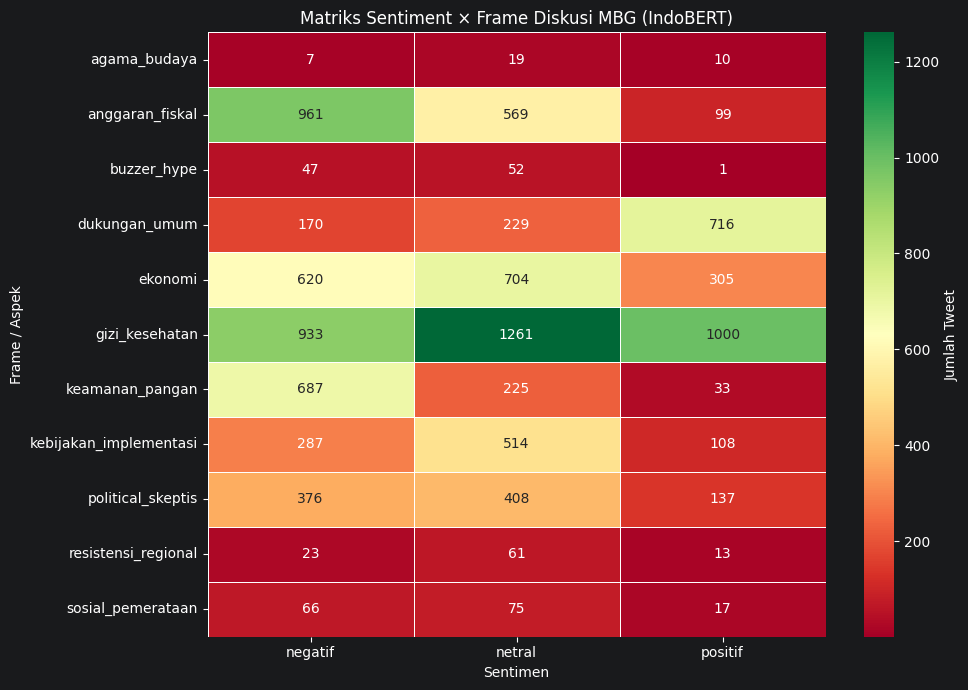

In [14]:
pivot_bert = pd.crosstab(df['frame_utama'], df['sentiment_bert'])
pivot_bert = pivot_bert.drop('tidak_terklasifikasi', errors='ignore')

sorted_idx = pivot_bert.sum(axis=1).sort_values(ascending=False).index
pivot_bert = pivot_bert.loc[pivot_bert.index.intersection(sorted_idx)]

# Heatmap Raw Count
plt.figure(figsize=(10, 7))
sns.heatmap(
    pivot_bert,
    annot=True, fmt='d',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Jumlah Tweet'}
)
plt.title('Matriks Sentiment × Frame Diskusi MBG (IndoBERT)')
plt.xlabel('Sentimen')
plt.ylabel('Frame / Aspek')
plt.tight_layout()
plt.show()


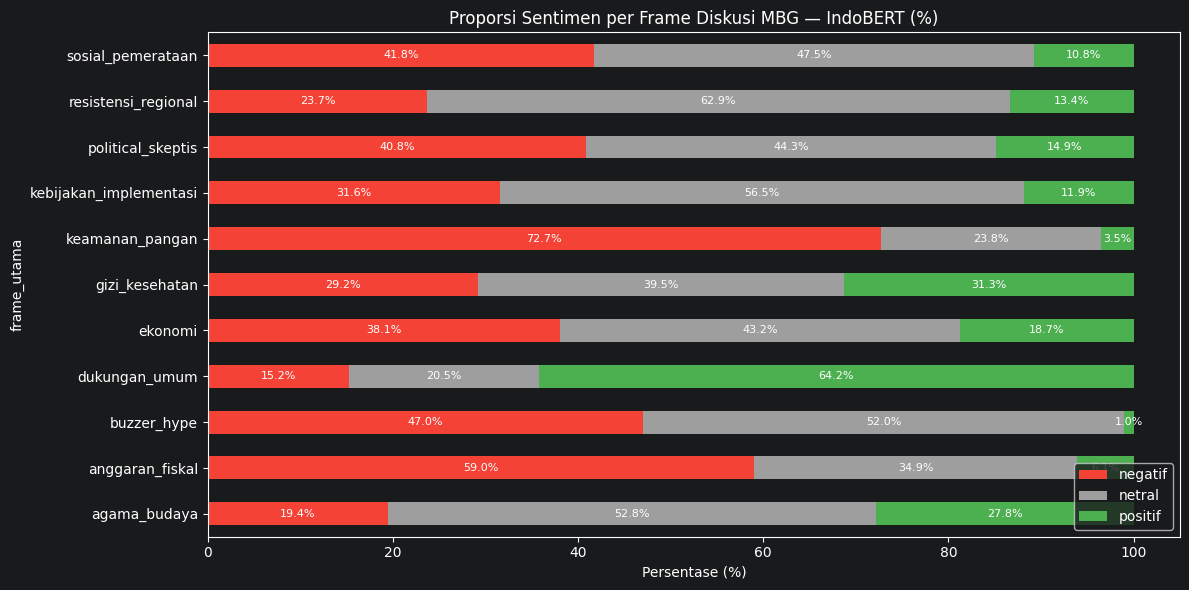

In [15]:
# Stacked Bar Proportion
pivot_bert_pct = pivot_bert.div(pivot_bert.sum(axis=1), axis=0) * 100
ax = pivot_bert_pct.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 6),
    color={'positif': '#4CAF50', 'negatif': '#F44336', 'netral': '#9E9E9E'}
)
plt.title('Proporsi Sentimen per Frame Diskusi MBG — IndoBERT (%)')
plt.xlabel('Persentase (%)')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [16]:
# Insight otomatis Count Based
print("=== INSIGHT OTOMATIS (IndoBERT) ===")
for frame in pivot_bert.index:
    row = pivot_bert.loc[frame]
    total = row.sum()
    if total > 0:
        neg_pct = row.get('negatif', 0) / total * 100
        pos_pct = row.get('positif', 0) / total * 100
        dominant = row.idxmax()
        print(f"{frame:<30} | pos {pos_pct:5.1f}% | neg {neg_pct:5.1f}% | dominan → {dominant}")

=== INSIGHT OTOMATIS (IndoBERT) ===
agama_budaya                   | pos  27.8% | neg  19.4% | dominan → netral
anggaran_fiskal                | pos   6.1% | neg  59.0% | dominan → negatif
buzzer_hype                    | pos   1.0% | neg  47.0% | dominan → netral
dukungan_umum                  | pos  64.2% | neg  15.2% | dominan → positif
ekonomi                        | pos  18.7% | neg  38.1% | dominan → netral
gizi_kesehatan                 | pos  31.3% | neg  29.2% | dominan → netral
keamanan_pangan                | pos   3.5% | neg  72.7% | dominan → negatif
kebijakan_implementasi         | pos  11.9% | neg  31.6% | dominan → netral
political_skeptis              | pos  14.9% | neg  40.8% | dominan → netral
resistensi_regional            | pos  13.4% | neg  23.7% | dominan → netral
sosial_pemerataan              | pos  10.8% | neg  41.8% | dominan → netral



=== SENTIMEN: Raw Count vs View-Weighted ===
                raw_count_%  view_weighted_%
sentiment_bert                              
negatif                39.7             41.5
netral                 37.3             45.2
positif                23.1             13.4

Analisis Gap View vs Raw:
[POSITIF]: gap -9.7% — Opini yang dilihat netizen berbeda secara signifikan dari sekadar menghitung jumlah tweet.
[NETRAL]: gap +7.9% — Opini yang dilihat netizen berbeda secara signifikan dari sekadar menghitung jumlah tweet.


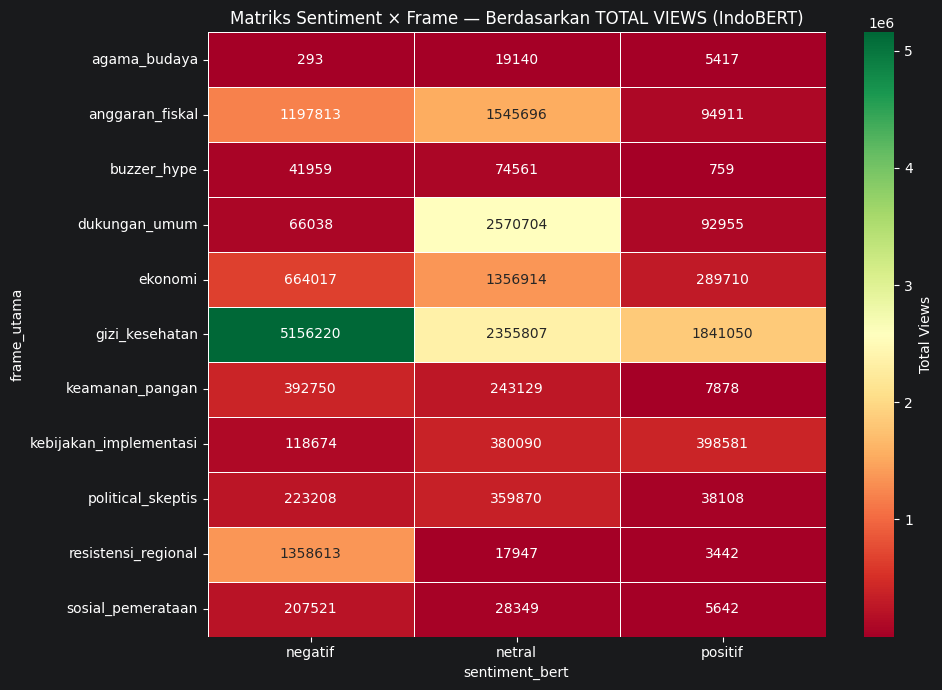

In [17]:

df['view_count'] = pd.to_numeric(df['view_count'], errors='coerce').fillna(0)
total_views = df['view_count'].sum()

raw_dist = df['sentiment_bert'].value_counts(normalize=True).mul(100).round(1)
view_dist = df.groupby('sentiment_bert')['view_count'].sum().div(total_views).mul(100).round(1)

comparison = pd.DataFrame({
    'raw_count_%': raw_dist,
    'view_weighted_%': view_dist
})
print("\n=== SENTIMEN: Raw Count vs View-Weighted ===")
print(comparison)

print("\nAnalisis Gap View vs Raw:")
for sent in ['positif', 'negatif', 'netral']:
    gap = view_dist.get(sent, 0) - raw_dist.get(sent, 0)
    if abs(gap) > 5:
        print(f"[{sent.upper()}]: gap {gap:+.1f}% — Opini yang dilihat netizen berbeda secara signifikan dari sekadar menghitung jumlah tweet.")

# Heatmap View-Weighted
pivot_bert_views = df.groupby(['frame_utama', 'sentiment_bert'])['view_count'].sum().unstack(fill_value=0)
pivot_bert_views = pivot_bert_views.drop('tidak_terklasifikasi', errors='ignore')

plt.figure(figsize=(10, 7))
sns.heatmap(pivot_bert_views, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Total Views'})
plt.title('Matriks Sentiment × Frame — Berdasarkan TOTAL VIEWS (IndoBERT)')
plt.tight_layout()
# plt.savefig('../Output/Figures/sentiment/heatmap_views_frame.png', dpi=150)
plt.show()

In [19]:
def hybrid_sentiment_correction(row):
    text = str(row['clean_text']).lower()
    bert_sent = row['sentiment_bert']

    # Kalau IndoBERT bilang Netral/Positif, tapi ada kata fatal -> PAKSA jadi Negatif
    if bert_sent != 'negatif' and any(kata in text for kata in kata_fatal):
        return 'negatif'

    # Kalau aman, percaya sama IndoBERT
    return bert_sent

df['sentiment_final'] = df.apply(hybrid_sentiment_correction, axis=1)

# Cek seberapa banyak yang berhasil "diselamatkan" dari salah deteksi
berubah = (df['sentiment_bert'] != df['sentiment_final']).sum()
print(f"Berhasil mengoreksi {berubah} tweet menjadi Negatif menggunakan pendekatan Hybrid!")

Berhasil mengoreksi 541 tweet menjadi Negatif menggunakan pendekatan Hybrid!


In [20]:
def classify_user_type(desc):
    if pd.isna(desc) or str(desc).strip() == "": return "no_bio"
    d = str(desc).lower()
    if any(k in d for k in ['relawan', 'projo', 'tim pemenangan', 'gibran']): return "relawan_politik"
    if any(k in d for k in ['wartawan', 'jurnalis', 'reporter', 'redaksi', 'media','portal']): return "media"
    if any(k in d for k in ['dokter', 'dr.', 'ahli gizi', 'nutrisi']): return "health_professional"
    if any(k in d for k in ['guru', 'dosen', 'mahasiswa', 'peneliti']): return "akademisi"
    if any(k in d for k in ['aktivis', 'ngo', 'lsm', 'advokasi','pemerhati',"aksi",'relativist']): return "aktivis"
    if any(k in d for k in ['wkwk', 'literally', 'bestie', '💀', '🫠', 'receh']): return "genz"
    if any(k in d for k in ['pengusaha', 'ceo', 'founder', 'bisnis']): return "bisnis"
    return "general_public"

df['user_type'] = df['user_description'].apply(classify_user_type)

print("=== SENTIMEN PER USER TYPE (IndoBERT) ===")
print(pd.crosstab(df['user_type'], df['sentiment_bert'], normalize='index').mul(100).round(1))

MBG_LAUNCH = pd.Timestamp("2025-01-06", tz='UTC')

df['user_created_at_dt'] = pd.to_datetime(df['user_created_at_dt'], utc=True, errors='coerce')
df['user_followers_count'] = pd.to_numeric(df['user_followers_count'], errors='coerce').fillna(0)
df['user_statuses_count'] = pd.to_numeric(df['user_statuses_count'], errors='coerce').fillna(0)

# Kriteria
df['is_new_account'] = df['user_created_at_dt'] >= MBG_LAUNCH
df['is_low_follower'] = df['user_followers_count'] < 100
df['is_high_activity'] = df['user_statuses_count'] > 500

df['buzzer_suspect'] = (
    df['is_new_account'] & df['is_low_follower'] & df['is_high_activity']
)

print(f"\n=== BUZZER DETECTION ===")
print(f"Total suspect akun buzzer: {df['buzzer_suspect'].sum()}")
print("\nDistribusi frame akun buzzer vs organik (Persentase):")
print(pd.crosstab(df['buzzer_suspect'], df['frame_utama'], normalize='index').mul(100).round(1))

=== SENTIMEN PER USER TYPE (IndoBERT) ===
sentiment_bert       negatif  netral  positif
user_type                                    
akademisi               30.5    47.5     22.0
aktivis                 46.3    35.3     18.4
bisnis                  33.9    53.6     12.5
general_public          41.1    36.6     22.4
genz                    53.8    30.8     15.4
health_professional     25.0    37.5     37.5
media                   12.1    77.3     10.6
no_bio                  38.7    33.6     27.7
relawan_politik         58.3    25.0     16.7

=== BUZZER DETECTION ===
Total suspect akun buzzer: 332

Distribusi frame akun buzzer vs organik (Persentase):
frame_utama     agama_budaya  anggaran_fiskal  buzzer_hype  dukungan_umum  \
buzzer_suspect                                                              
False                    0.2             10.9          0.6            7.5   
True                     0.0              9.9          1.5            6.0   

frame_utama     ekonomi  gizi_k

In [22]:
cols_baru = ['user_type', 'buzzer_suspect', 'is_new_account',
             'score_positif', 'score_negatif', 'score_netral',
             'keamanan_subframe', 'mention_count', 'view_count',"sentiment_final"]

print("Status Kolom Baru:")
for c in cols_baru:
    if c in df.columns:
        print(f"Ada - {c}")
    else:
        print(f"{c} — Belum ada!")

# Pastikan folder target tersedia
os.makedirs(os.path.dirname(ANALYZED_DATA), exist_ok=True)

# Export Data
df.to_csv(ANALYZED_DATA, index=False)
print(f"\nData Tersimpan ke: {ANALYZED_DATA}")
print(f"  Shape: {len(df)} baris, {len(df.columns)} kolom")

Status Kolom Baru:
Ada - user_type
Ada - buzzer_suspect
Ada - is_new_account
Ada - score_positif
Ada - score_negatif
Ada - score_netral
Ada - keamanan_subframe
Ada - mention_count
Ada - view_count
Ada - sentiment_final

Data Tersimpan ke: /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Competition/SatriaData/2026/internalTus/Data/Analyzed/mbg_analyzed.csv
  Shape: 15000 baris, 53 kolom
